## Image Classification with CNN for Helmet Detection

This notebook demonstrates how to build and train a Convolutional Neural Network (CNN) to classify images into two categories: 'wearing helmet' and 'not wearing helmet'.

**Assumptions:**
*   You have your images organized into two subdirectories within a main directory, for example:
    ```
    data/
    ├── wearing helmet/
    │   ├── image1.jpg
    │   ├── image2.png
    │   └── ...
    └── not wearing helmet/
        ├── imageA.jpg
        ├── imageB.jpeg
        └── ...
    ```
*   You will need to adjust the `data_dir` variable to point to your main directory containing these two subfolders.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

# Define the path to your dataset
# IMPORTANT: Update this path to where your 'wearing helmet' and 'not wearing helmet' folders are located.
data_dir = '/content/sample_data' # Example: if your folders are in a 'data' directory in the Colab environment

# Check if the directory exists
if not os.path.exists(data_dir):
    print(f"Error: Directory '{data_dir}' not found. Please upload your dataset or update the 'data_dir' variable.")
    # You might want to create dummy directories for demonstration or prompt the user.
    # For this example, let's create some dummy directories if they don't exist
    print("Creating dummy directories for demonstration.")
    os.makedirs(os.path.join(data_dir, 'wearing helmet'), exist_ok=True)
    os.makedirs(os.path.join(data_dir, 'not wearing helmet'), exist_ok=True)
    print("Please upload your images into these folders or provide the correct 'data_dir'.")

### 1. Load and Preprocess Data

We'll use `tf.keras.utils.image_dataset_from_directory` to load the images. This utility automatically infers class labels from the directory structure and creates a `tf.data.Dataset`.

In [ ]:
# Define image dimensions and batch size
img_height = 128
img_width = 128
batch_size = 32

# Define data split percentages (70% train, 30% test)
test_split_ratio = 0.3 # This will be used as validation_split to create the test set

# Load the training dataset (70% of total data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=test_split_ratio,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load the test dataset (30% of total data)
# We use the 'validation' subset from image_dataset_from_directory as our test set for a 70-30 split.
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=test_split_ratio,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Get class names
class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Print number of batches for each dataset
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds)}")

# Note: In this 70-30 train-test split, there is no separate 'val_ds' for monitoring during training.
# If a validation set is desired, a portion of the 'train_ds' would typically be set aside.
# For now, we proceed with a direct train-test split as requested.

Found 640 files belonging to 2 classes.
Using 448 files for training.
Found 640 files belonging to 2 classes.
Using 192 files for validation.
Class names: ['Not Wearing Helmet', 'Wearing Helmet']
Number of training batches: 14
Number of test batches: 6


### 2. Configure Dataset for Performance

Use `cache()` and `prefetch()` to optimize data loading for training.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
# val_ds was removed in the 70/30 train-test split, so remove its prefetching
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### 3. Build the CNN Model

We'll create a simple CNN architecture. It includes:
*   **Rescaling layer**: Normalizes pixel values to [0, 1].
*   **Data Augmentation**: To improve model generalization (optional, but good practice).
*   **Convolutional layers (Conv2D)**: Extract features from images.
*   **Max Pooling layers (MaxPooling2D)**: Downsample feature maps.
*   **Flatten layer**: Converts 2D feature maps to 1D vector.
*   **Dense layers**: Fully connected layers for classification.

In [ ]:
num_classes = len(class_names)

# Data augmentation layers
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

# Define the input layer
inputs = keras.Input(shape=(img_height, img_width, 3))

# Apply data augmentation
x = data_augmentation(inputs)

# Rescaling
x = layers.Rescaling(1./255)(x)

# Convolutional layers
x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)

# Flatten and Dense layers for classification
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes)(x) # Output layer with `num_classes` units

# Create the model using the functional API
model = keras.Model(inputs=inputs, outputs=outputs)

### 4. Compile the Model

We need to specify the optimizer, loss function, and metrics.
*   **Optimizer**: `Adam` is a popular choice.
*   **Loss function**: Since this is a binary classification (wearing helmet vs. not wearing helmet), `SparseCategoricalCrossentropy` is suitable if the labels are integers (as provided by `image_dataset_from_directory`). If you were using one-hot encoded labels, you would use `CategoricalCrossentropy`.
*   **Metrics**: `accuracy` to monitor performance.

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,122 (8.09 MB)

 Trainable params: 2,121,122 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Train the Model

Now, let's train the model using our training and validation datasets. You can adjust the number of `epochs`.

In [ ]:
epochs = 10 # You can increase this for better performance
history = model.fit(
    train_ds,
    # With a 70/30 train-test split, we don't have a separate validation_data for fit.
    # If a validation set is desired, it should be explicitly created from train_ds.
    # validation_data=val_ds, # Removed as val_ds is no longer defined
    epochs=epochs
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.5826 - loss: 0.7888
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7054 - loss: 0.6044
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7009 - loss: 0.5586
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7433 - loss: 0.5190
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7612 - loss: 0.4692
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7946 - loss: 0.4394
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8036 - loss: 0.4155
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8058 - loss: 0.4197
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8237 - loss: 0.3893
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8192 - loss: 0.4007


### 6. Evaluate the Model

After training, let's evaluate the model's performance on the unseen test set.

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test loss: {loss:.2f}")
print(f"Test accuracy: {accuracy:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.8177 - loss: 0.4249
Test loss: 0.42
Test accuracy: 0.82


### 7. Visualize Training Results

It's good practice to visualize the training and validation accuracy and loss over epochs.

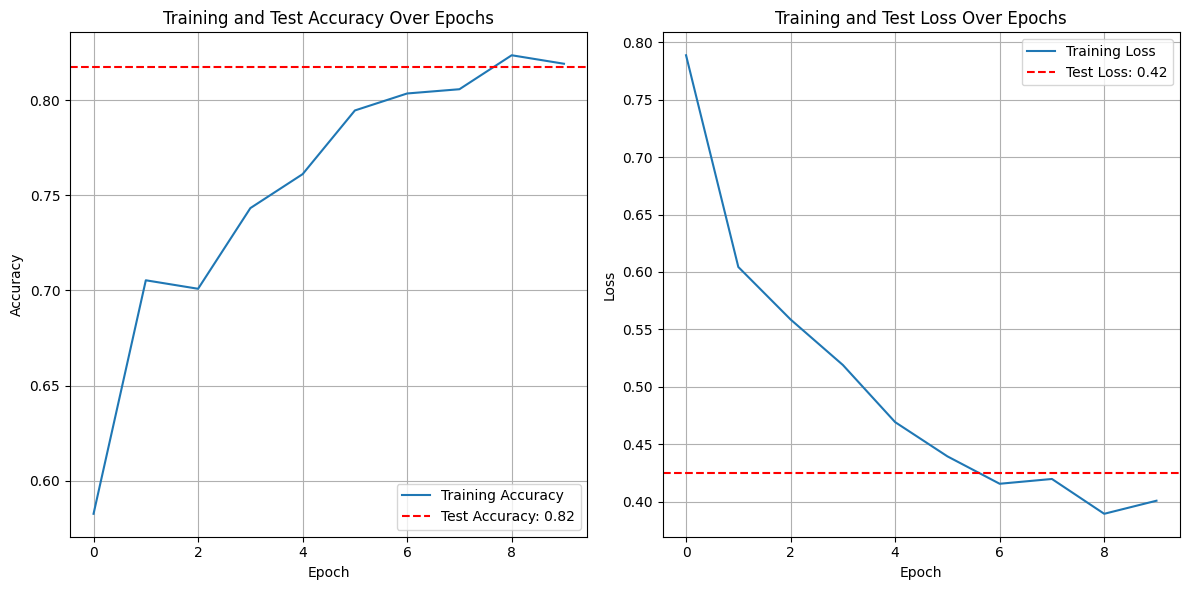

In [ ]:
import numpy as np

# Get training metrics from history
train_acc = history.history['accuracy']
train_loss = history.history['loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))

# Plot Training Accuracy and Test Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.axhline(y=accuracy, color='r', linestyle='--', label=f'Test Accuracy: {accuracy:.2f}')
plt.legend(loc='lower right')
plt.title('Training and Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training Loss and Test Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.axhline(y=loss, color='r', linestyle='--', label=f'Test Loss: {loss:.2f}')
plt.legend(loc='upper right')
plt.title('Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Print final training accuracy and test accuracy
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.2f}")
print(f"Test Accuracy: {accuracy:.2f}")

Final Training Accuracy: 0.82
Test Accuracy: 0.82


This simple cell just prints out the numerical values for the final training accuracy and the test accuracy. This gives you a quick, clear look at these key performance indicators at the end of the training and evaluation process.

### 8. Make Predictions on a New Image

This section provides code to load a new image, preprocess it, and use the trained model to predict whether the person in the image is wearing a helmet or not.

Saving imgi_42_default.jpg to imgi_42_default.jpg
User uploaded file "imgi_42_default.jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
This image most likely belongs to Not Wearing Helmet with a 95.81% confidence.


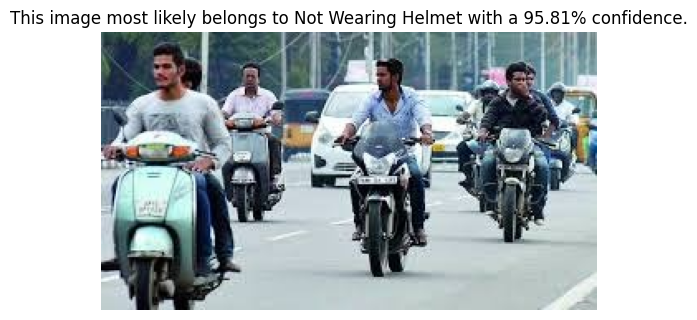

In [ ]:
from tensorflow.keras.preprocessing import image
from google.colab import files
import io
import numpy as np # Ensure numpy is imported for np.expand_dims
import os # Ensure os is imported for os.remove

# Function to load and preprocess an image for prediction
def preprocess_image_for_prediction(img_path):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Create a batch
    return img_array

# Option 1: Upload a new image
# uploaded = files.upload()

# Option 2: Use an image from your training data (uncomment and modify path)
# For example, to use an image from the 'wearing helmet' class in your training data:
# Replace 'path/to/your/image.jpg' with an actual image path from your 'data_dir'
# For example, if your `data_dir` is '/content/sample_data', and you have images in '/content/sample_data/wearing helmet/'
# new_image_path = '/content/sample_data/wearing helmet/some_image.jpg'

# For this demonstration, we'll use the upload functionality again.
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    # Save the uploaded file temporarily
    with open(fn, 'wb') as f:
        f.write(uploaded[fn])

    # Preprocess the uploaded image
    new_image_path = fn
    img_for_prediction = preprocess_image_for_prediction(new_image_path)

    # Make a prediction
    predictions = model.predict(img_for_prediction)
    score = tf.nn.softmax(predictions[0])

    # Format the prediction string
    prediction_text = f"This image most likely belongs to {class_names[np.argmax(score)]} with a {100 * np.max(score):.2f}% confidence."

    # Print the prediction explicitly
    print(prediction_text)

    # Display the image and prediction
    plt.imshow(image.load_img(new_image_path))
    plt.axis('off')
    plt.title(prediction_text) # Use the same formatted string for the title
    plt.show()

    # Clean up the uploaded file
    os.remove(fn)

### 9. Generate Classification Report

To get a more detailed understanding of the model's performance, especially for each class, we can generate a classification report that includes precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from test_ds
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Get predictions from the model on the test_ds
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1) # Convert logits to predicted class indices

# Generate and print the classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:

                    precision    recall  f1-score   support

Not Wearing Helmet       0.81      0.80      0.80        89
    Wearing Helmet       0.83      0.83      0.83       103

          accuracy                           0.82       192
         macro avg       0.82      0.82      0.82       192
      weighted avg       0.82      0.82      0.82       192



### 10. Overall Accuracy and Confusion Matrix

Beyond the classification report, we can also explicitly show the overall accuracy and visualize the confusion matrix. The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class.

Overall Test Accuracy: 0.82



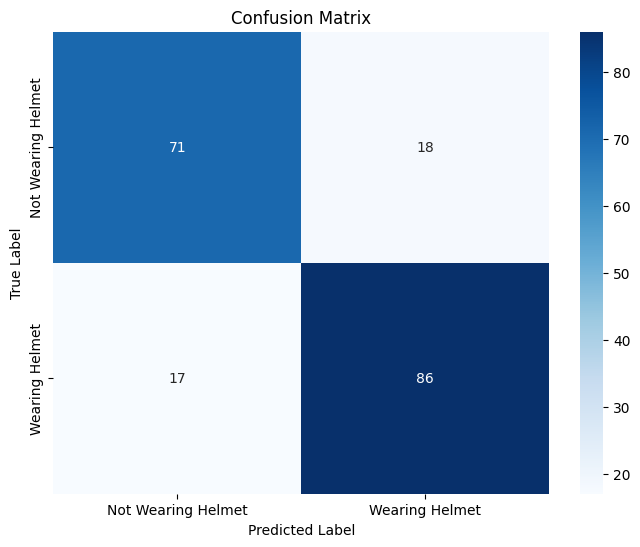

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate overall accuracy (already available from model.evaluate, but good to show explicitly)
overall_accuracy = np.sum(y_true == y_pred) / len(y_true)
print(f"Overall Test Accuracy: {overall_accuracy:.2f}\n")

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()